In [2]:
"""
/*----------------------------------------------------------------------------+
|                                                                             |
|                   copyright (c) 2022 by MVM.                                |
|                                                                             |
+-------------+---------------------------------------------------------------+
| producto:   | Mexico                                                        |
| Tema:       | Pronóstico blue energy mexico                                 |
| programa:   | blue_energy_20220218.py                                       |
| soporte:    | kevin.hidalgo@mvm.com.co                                      |
| version:    | 1.0                                                           |
| lenguaje:   | Python 3.7.12 google colab                                    |
+-------------+---------------------------------------------------------------+
| CD:         | 18/02/2022                                                    |
| LUD:        | 18/02/2022                                                    |
| Descripción:| Pruebas                                                       |
+-------------+---------------------------------------------------------------+
| parametros: |                                                               |
+-------------+---------------------------------------------------------------+
| Salidas   : |                                                               |
| Generadas   |                                                               |
+-------------+---------------------------------------------------------------+
| comentarios:|                                                               |
+-------------+---------------------------------------------------------------+
| Autor(es):  | Kevin Hidalgo | Consultor analítico                           |
+-------------+--------------+-----------+-----------------------------------*/
"""

## Leyendo los datos de Google Drive
## Se debe pegar una clave que se obtiene del link
from google.colab import drive
drive.mount('/content/gdrive')
!python --version
!ls Python --version
!ls '/content/gdrive/My Drive/Semestre actual/mvm_mexico/'

Mounted at /content/gdrive
Python 3.7.12
ls (GNU coreutils) 8.28
Copyright (C) 2017 Free Software Foundation, Inc.
License GPLv3+: GNU GPL version 3 or later <http://gnu.org/licenses/gpl.html>.
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.

Written by Richard M. Stallman and David MacKenzie.
data  developer  README.md


## Librerías

In [1]:
import datetime as date
import warnings
from datetime import datetime, timedelta
from time import localtime, strftime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#!pip install git+https://github.com/statsmodels/statsmodels
!pip install pmdarima
import pmdarima as pm
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
from numpy import arange
from pmdarima.arima.utils import ndiffs, nsdiffs
from scipy import stats
from scipy.special import boxcox1p, inv_boxcox1p
from scipy.stats import t
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LassoCV, Ridge
from sklearn.model_selection import RepeatedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
!pip install u8darts
from darts import TimeSeries
from darts.utils.statistics import check_seasonality

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rc('figure',figsize=(16,9))
plt.rc('font',size=14)

## Funciones auxiliares

In [2]:
def fn_date_start():
    """
    #-------------------------------------------------------------------------
    #---------------- Captura el tiempo de inicio del proceso ----------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #-----------
    #
    # Returns
    #--------
    # incp : date
    #     Tiempo en formato posixct.
    #
    # usage
    #------
    # vIncp = fn_date_start()
    """
    print("######################################################")
    print("## Hora inicio proceso -> " + strftime("%a, %d %b %Y %H:%M:%S",
                                                  localtime()) + " ##")
    print('######################################################')
    incp = None
    incp = date.datetime.now()
    return incp

def fn_date_end():
    """
    #-------------------------------------------------------------------------
    #------------------ Captura el tiempo de fin del proceso -----------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #-----------
    #
    # Returns
    #-------
    # fnpr : date
    #     Tiempo en formato posixct.
    #
    # usage
    #------
    # vFnpr = fn_date_end()
    #
    """
    print("######################################################")
    print("## Hora fin proceso -> " + strftime("%a, %d %b %Y %H:%M:%S",
                                               localtime()) + " #####")
    print("######################################################")
    fnpr = None
    fnpr = date.datetime.now()
    return fnpr

def fn_runtime(tiempo_inicial, tiempo_final):
    """
    #-------------------------------------------------------------------------
    #--------------- Retorna el tiempo de ejecución del proceso --------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #-----------
    # tiempo_inicial : TYPE
    #     Tiempo inicio del proceso en formato posixct.
    # tiempo_final : TYPE
    #     Tiempo final del proceso en formato posixct.
    #
    # Returns
    # -------
    # None.
    #
    # usage
    #------
    # fn_runtime(vIncp, vFnpr)
    #
    """
    total_time = None
    total_time = tiempo_final - tiempo_inicial
    print("######################################################")
    print("## El tiempo total de ejecución fue: " + str(total_time) + " ##")
    print("######################################################")

def fn_conviertestringenfloat(dataframe, columna):
    """
    #-------------------------------------------------------------------------
    #---- Convierte una columna  de un dataframe de tipo object en tipo  -----
    #---- float.                                                          ----
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #-----------
    # dataframe: Dataframe
    #     dataframe con columnas tipo object.
    # columna: string
    #     nombre de la columna a convertir.
    #
    # Returns
    # -------
    # dataframe : dataframe
    #     Columna del dataframe tipo float.
    #
    # usage
    #------
    # dataframe['columna'] = fn_conviertestringenfloat(dataframe, 'columna')
    #
    """
    return dataframe[columna].apply(lambda x: float(str(x).replace(",", ".")))

def data_wrangling(dataframe, dict_prmt):
    """ Data Wrangling
    #
    # Parameters:
    #-----------
    # dataframe: DataFrame
    #     Dataframe de trabajo.
    # dict_prmt: dict
    #     Diccionario de parámetros.
    #
    # Return:
    #-------
    # df_tmp: DataFrame
    #     dataframe con columnas adicionales.
    #
    # Usage:
    #------
    # dataframe = data_wrangling(dataframe, dict_prmt)
    """
    df_tmp = dataframe.copy()
    df_tmp = df_tmp.filter(regex=(dict_prmt["operador"]))
    tmp_string = "total_energia_activa_"
    tmp_string = tmp_string +  dict_prmt["nombre"]
    df_tmp[tmp_string] = np.sum(
        df_tmp.filter(regex=(dict_prmt["nombre"])),
        axis = 1
    )
    tmp_string = "cenace_"
    tmp_string = tmp_string +  dict_prmt["nombre"]
    df_tmp[tmp_string] = (
        np.sum(df_tmp.filter(regex=("cenace")), axis = 1)
        * -1
    )
    tmp_string_1 = "cenace_abs_"
    tmp_string_1 = tmp_string_1 +  dict_prmt["nombre"]
    df_tmp[tmp_string_1] = np.abs(df_tmp[tmp_string])
    tmp_string_2 = "participante_"
    tmp_string_2 = tmp_string_2 +  dict_prmt["nombre"]
    df_tmp[tmp_string_2] = np.sum(
        df_tmp.filter(regex=("partic")),
        axis = 1
    )
    tmp_string_1 = "total_valor_bruto_"
    tmp_string_1 = tmp_string_1 +  dict_prmt["nombre"]
    df_tmp[tmp_string_1] = (df_tmp[tmp_string] + df_tmp[tmp_string_2])
    tmp_string = "total_energia_activa_"
    tmp_string = tmp_string +  dict_prmt["nombre"]
    tmp_string_2 = "precio_compra_"
    tmp_string_2 = tmp_string_2 +  dict_prmt["nombre"]
    df_tmp[tmp_string_2] = (
        df_tmp[tmp_string_1]/df_tmp[tmp_string]
    )
    tmp_string = "precio_compra_abs_"
    tmp_string = tmp_string +  dict_prmt["nombre"]
    df_tmp[tmp_string] = np.abs(df_tmp[tmp_string_2])
    tmp_string_2 = "total_valor_bruto_abs_"
    tmp_string_2 = tmp_string_2 +  dict_prmt["nombre"]
    df_tmp[tmp_string_2] = np.abs(df_tmp[tmp_string_1])
    df_tmp["dt_val"] = dataframe["dt_val"]
    df_tmp["year"] = df_tmp.dt_val.dt.year
    df_tmp["month"] = df_tmp.dt_val.dt.month
    df_tmp["day"] = df_tmp.dt_val.dt.day
    df_tmp["fecha_dt_val_tem"] = (
        df_tmp.year * 10000
        + df_tmp.month * 100
        + df_tmp.day
    )
    df_costo_cels = dict_prmt["df_costo_cels"]
    df_tmp = pd.merge(df_tmp, df_costo_cels, how= "left", on="year")
    tmp_string = "costo_cels_"
    tmp_string = tmp_string +  dict_prmt["nombre"]
    tmp_string_1 = "total_energia_activa_"
    tmp_string_1 = tmp_string_1 + dict_prmt["nombre"]
    df_tmp[tmp_string] = (
        df_tmp[tmp_string_1]
        * df_tmp["multiplic"]
    )
    tmp_string_2 = "costo_energia_"
    tmp_string_2 = tmp_string_2 + dict_prmt["nombre"]
    tmp_string_3 = "precio_compra_"
    tmp_string_3 = tmp_string_3 + dict_prmt["nombre"]
    df_tmp[tmp_string_2] = (
        df_tmp[tmp_string_1]
        * df_tmp[tmp_string_3]
    )
    tmp_string_3 = "costo_energia_abs_"
    tmp_string_3 = tmp_string_3 + dict_prmt["nombre"]
    df_tmp[tmp_string_3] = np.abs(df_tmp[tmp_string_2])
    tmp_string_1 = "costo_"
    tmp_string_1 = tmp_string_1 + dict_prmt["nombre"]
    df_tmp[tmp_string_1] = (
        df_tmp[tmp_string_3]
        + df_tmp[tmp_string]
    )
    df_config = dict_prmt["df_config"]
    df_tmp = pd.merge(df_tmp, df_config, how= "left", on="year")
    tmp_string_1 = "precio_venta_"
    tmp_string_1 = tmp_string_1 + dict_prmt["nombre"]
    df_tmp.rename(columns = {'valor':tmp_string_1}, inplace = True)
    tmp_string_2 = "total_energia_activa_"
    tmp_string_2 = tmp_string_2 + dict_prmt["nombre"]
    tmp_string_3 = "diff_prcn_"
    tmp_string_3 = tmp_string_3 + dict_prmt["nombre"]
    df_tmp[tmp_string_3] = df_tmp[tmp_string_2].pct_change(axis=0,fill_method='bfill') * 100
    tmp_string_1 = "diff_prcn_costo_cels_"
    tmp_string_1 = tmp_string_1 + dict_prmt["nombre"]
    df_tmp[tmp_string_1] = df_tmp[tmp_string].pct_change(axis=0,fill_method='bfill') * 100
    tmp_string = "abs_diff_prcn_"
    tmp_string = tmp_string + dict_prmt["nombre"]
    df_tmp.loc[:,tmp_string] = np.abs(df_tmp[tmp_string_3])
    tmp_string_2 = "abs_diff_prcncosto_cels_"
    tmp_string_2 = tmp_string_2 + dict_prmt["nombre"]
    df_tmp.loc[:,tmp_string_2] = np.abs(df_tmp[tmp_string_1])
    return df_tmp

def fn_forecast_accuracy(forecast, actual):
    """
    #-------------------------------------------------------------------------
    #------------ Genera medidas de precisión sobre la predicción ------------
    #----------------------- @author: Esteban Martinez -----------------------
    #
    # Parameters
    #----------
    # forecast : array
    #     pronóstico en t + n.
    # actual : array
    #     test en t + n.
    #
    # Returns
    #-------
    # array con los siguientes estadísticos: MAPE, ME, MAE, MPE, RMSE.
    #
    # usage
    #------
    # metrica = fn_forecast_accuracy(forecast, actual)
    #
    """
    mtrc_mape = None
    mtrc_me = None
    mtrc_mae = None
    mtrc_mpe = None
    mtrc_rmse = None
    mtrc_mape = (np.mean(np.abs(forecast - actual)/np.abs(actual)))*100  # MAPE
    mtrc_me = np.mean(forecast - actual)             # ME
    mtrc_mae = np.mean(np.abs(forecast - actual))    # MAE
    mtrc_mpe = np.mean((forecast - actual)/actual)   # MPE
    mtrc_rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    return({'mape':mtrc_mape, 'me':mtrc_me, 'mae': mtrc_mae,
            'mpe': mtrc_mpe, 'rmse':mtrc_rmse})

def test_stationarity(timeseries):
    """
    # pendiente
    """
    #Determing rolling statistics
    rolmean = pd.Series(timeseries).rolling(window=7).mean()
    rolstd = pd.Series(timeseries).rolling(window=7).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic','p-value','#Lags Used','Number of Observations Used']
    )
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

def fn_split_data(dataframe, dic_prmt):
    """
    #-------------------------------------------------------------------------
    #-------------- Particiona el dataframe creando train y test -------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #----------
    # dataframe : dataframe
    #     dataframe de trabajo.
    # dic_prmt: dict
    #     Diccionario de parámetros.
    #
    # Returns
    #-------
    # dict_resultado : diccionario
    #     Diccionario que contiene dos dataframes (train,test) y dos series
    #     (train, test).
    #
    # usage
    #------
    # dict_ejemplo = split_data(dataframe,dic_prmt)
    #
    # Observaciones
    #-------------
    # var_1: variable de estudio.
    # num_splits: Number of splits. Must be at least 2.
    # tiempo: variable de tiempo
    """
    var_incp = None
    var_fnpr = None
    temporal = None
    dict_resultado = dict()
    df_x = pd.DataFrame()
    sr_y = pd.DataFrame()
    print("######################################################")
    print("#####                  Split Data                 ####")
    print("######################################################")
    var_incp = fn_date_start()
    temporal = TimeSeriesSplit(n_splits = dic_prmt["num_splits"])
    df_x = dataframe
    sr_y = dataframe[dic_prmt["var_1"]]
    for train_index, test_index in temporal.split(df_x):
        x_train, x_test = df_x.iloc[train_index, :], df_x.iloc[test_index,:]
        y_train, y_test = sr_y.iloc[train_index], sr_y.iloc[test_index]
    dict_resultado["origin"] = sr_y # serie
    dict_resultado["tiempo_origin"] = df_x[dic_prmt["tiempo"]] # tiempo original
    dict_resultado["n"] = len(sr_y) # longitud serie
    dict_resultado["x_train"] = x_train #dataframe
    dict_resultado["x_test"] = x_test #dataframe
    dict_resultado["y_train"] = y_train #serie
    dict_resultado["y_test"] = y_test #serie
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dict_resultado

def fn_orden_estacional(dic_prmt, var_alpha = 0.05):
    """
    #-----------------------------------------------------------------------
    #---------- Retorna el orden estacional de la serie de tiempo ----------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # dic_prmt: dict
    #     Diccionario de parámetros.
    # var_alpha: float
    #     significance level default
    #
    # Returns
    # -------
    # dic_prmt: dict
    #     Diccionario de parámetros.
    #
    # usage
    #------
    # base = fn_ma_outlier(df_orgn, window)
    #
    """
    var_incp = None
    var_fnpr = None
    series = None
    mseas = None
    is_seasonal = None
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####              Orden estacional               ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_tmp["serie"] = dic_prmt["origin"]
    df_tmp["tiempo"] = dic_prmt["tiempo_origin"]
    series = TimeSeries.from_dataframe(df_tmp, "tiempo", "serie")
    # regular
    df_tmp = df_tmp.set_index("tiempo")
    res = (pd.Series(df_tmp.index[1:]) - pd.Series(df_tmp.index[:-1])).value_counts()
    res.index[0]
    if pd.infer_freq(df_tmp.index) == "D" or pd.infer_freq(df_tmp.index) == "d":
        dic_prmt["freq"] = 365
    elif pd.infer_freq(df_tmp.index) == "Y" or pd.infer_freq(df_tmp.index) == "A-DEC":
        dic_prmt["freq"] = 1
    elif pd.infer_freq(df_tmp.index) == "m" or pd.infer_freq(df_tmp.index) == "M":
        dic_prmt["freq"] = 12
    elif pd.infer_freq(df_tmp.index) == "q" or pd.infer_freq(df_tmp.index) == "Q-DEC":
        dic_prmt["freq"] = 4
    elif pd.infer_freq(df_tmp.index) == "w" or pd.infer_freq(df_tmp.index) == "W-SUN":
        dic_prmt["freq"] = 52
    elif pd.infer_freq(df_tmp.index) == "h" or pd.infer_freq(df_tmp.index) == "H":
        dic_prmt["freq"] = 24
    else:
        dic_prmt["freq"] = None
    print("Frequency = {} -> {}".format(pd.infer_freq(df_tmp.index),dic_prmt["freq"]))
    # check for seasonality, via ACF
    for m in range(2, 25):
        is_seasonal, mseas = check_seasonality(series, m=m, alpha=var_alpha)
        if is_seasonal:
            break
    print("seasonal? " + str(is_seasonal))
    if is_seasonal:
        print('There is seasonality of order {}.'.format(mseas))
    dic_prmt["nsdiff"] = mseas
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_transformaciones_bxcx(dic_prmt):
    """
    #-------------------------------------------------------------------------
    #-- Genera diccionario con serie de tiempo con transformación de Box-Cox -
    #---- según Lambda, además genera los valores del test ADF, diferencia ---
    #------------- regular (bool) y diferencia estacional (bool). ------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #----------
    # dic_prmt : diccionario
    #     Diccionario que contiene los dataframes de train and test y además
    #     contiene las series de train and test.
    #
    # Returns
    #-------
    # diccionario : diccionario
    #     anexa al diccionario de entrada las variables zt, lambda, ADF,
    #     diferencia regular y diferencia estacional.
    # usage
    #------
    # dict_ejemplo = transformaciones_BxCx(dic_prmt)
    #
    # Observaciones
    #-------------
    # | Values of $\lambda$(lambda) |        transformation       |
    # |:---------------------------:|:---------------------------:|
    # |             -1.0            |      $\frac{1}{Z_{t}}$      |
    # |             -0.5            |   $\frac{1}{\sqrt{Z_{t}}}$  |
    # |             0.0             |   $\ln\left(Z_{t}\right)$   |
    # |             0.5             |        $\sqrt{Z_{t}}$       |
    # |             1.0             | $Z_{t}$ (no transformation) |
    #
    # |    Data   | frequency |
    # |:---------:|:---------:|
    # |   Annual  |     1     |
    # | Quarterly |     4     |
    # |  Monthly  |     12    |
    # |   Weekly  |     52    |
    #
    # var_1: variable de estudio.
    # nsdiff: el número de períodos estacionales (es decir, la frecuencia de la
    #     serie de tiempo)
    # nsdiff_max : int
    #     número máximo de las diferencias estacionales permitido. debe ser un
    #     número entero positivo.
    """
    y_train = None
    zt_tmp = None
    var_tem = None
    y_bxcx = None
    var_lmbda = None
    x_tem = None
    var_incp = None
    var_fnpr = None
    print("######################################################")
    print("#####           BoxCox, ADF, KPSS, OCSB           ####")
    print("######################################################")
    var_incp = fn_date_start()
    y_train = pd.Series(dic_prmt["y_train"], name = dic_prmt["var_1"])
    zt_tmp = y_train[y_train == 0]
    if len(zt_tmp) != 0:
        var_tem = y_train[y_train > 0]
        y_bxcx = stats.boxcox(var_tem)
        var_lmbda = y_bxcx[1]
        y_bxcx = boxcox1p(y_train, var_lmbda)
        x_tem = np.empty_like(y_train)
        x_tem = y_bxcx[0]
        x_tem = pd.Series(x_tem , index = y_train.index, name = dic_prmt["var_1"])
    else:
        y_bxcx = stats.boxcox(y_train)
        var_lmbda = y_bxcx[1]
        x_tem = np.empty_like(y_train)
        x_tem = y_bxcx[0]
        x_tem = pd.Series(x_tem , index = y_train.index, name = dic_prmt["var_1"])
    #conclusion
    if var_lmbda >= 1:
        print("La serie no requiere transformación de Box-Cox")
        zt_serie = x_tem
        dic_prmt["zt_BxCx"] = zt_serie
        dic_prmt["lmbda"] = var_lmbda
        dic_prmt["ADF"] = adfuller(zt_serie.dropna(inplace= False))
        dic_prmt["diferencia_regular"] = ndiffs(
            zt_serie.dropna(inplace=False),
            test="kpss"
        )
        dic_prmt["diferencia_estacional"] = nsdiffs(
            zt_serie.dropna(inplace=False),
            m = dic_prmt["nsdiff"],
            max_D = dic_prmt["nsdiff_max"],
            test = "ocsb"
        )
    else:
        zt_serie = x_tem
        print("La serie requiere transformación de Box-Cox con labmda = %f" % var_lmbda)
        dic_prmt["zt_BxCx"] = zt_serie
        dic_prmt["lmbda"] = var_lmbda
        dic_prmt["ADF"] = adfuller(zt_serie.dropna(inplace= False))
        dic_prmt["diferencia_regular"] = ndiffs(
            zt_serie.dropna(inplace=False),
            test="kpss"
        )
        dic_prmt['diferencia_estacional'] = nsdiffs(
            zt_serie.dropna(inplace=False),
            m = dic_prmt["nsdiff"],
            max_D = dic_prmt["nsdiff_max"],
            test = "ocsb"
        )
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_diferenciacion_serie(dic_prmt):
    """
    #-------------------------------------------------------------------------
    #----- Comprueba raíces unitarias usando el test KPSS, en caso de ser ----
    #------- necesario realizará diferenciación regular y/o estacional. ------
    # H0: Es estacionaria
    # H1: Tiene raíz unitaria
    #------------------------- @author: Kevin Hidalgo ------------------------
    # Parameters
    #----------
    # dic_prmt : diccionario
    #     Contiene parámetros y serie de tiempo.
    #
    # Returns
    #-------
    # dic_prmt : dict
    #     Diccionario que contiene la serie de tiempo, número de diferencias
    #     regular y número de diferencias estacionales.
    #
    # usage
    #------
    # dict_ejemplo = diferenciacion_serie(dic_prmt)
    #
    # Observaciones
    #-------------
    # Requiere diferencia regular (1) en caso contrario (0).
    """
    control_u = None
    control_v = None
    sr_zt = None
    var_incp = None
    var_fnpr = None
    print("######################################################")
    print("#####                   Diff Z_t                  ####")
    print("######################################################")
    var_incp = fn_date_start()
    control_u = dic_prmt["diferencia_regular"]
    control_v = dic_prmt["diferencia_estacional"]
    sr_zt = dic_prmt["zt_BxCx"]
    while dic_prmt["diferencia_regular"] > 0 or dic_prmt["diferencia_estacional"] > 0:
        if  dic_prmt["diferencia_regular"] != 0 and dic_prmt["diferencia_estacional"] !=0:
            sr_zt = sr_zt - sr_zt.shift(1)
            sr_zt = sr_zt - sr_zt.shift(dic_prmt["nsdiff"])
            dic_prmt["diferencia_regular"] = ndiffs(
                sr_zt.dropna(inplace=False),
                test="kpss"
            )
            dic_prmt["diferencia_estacional"] = nsdiffs(
                sr_zt.dropna(inplace=False),
                m=dic_prmt["nsdiff"],
                max_D=dic_prmt["nsdiff_max"],
                test="ocsb"
            )
            print(
                "diferencia regular: %d diferencia estacional %d" % (
                    dic_prmt["diferencia_regular"],
                    dic_prmt["diferencia_estacional"]
                )
            )
            control_u += 1
            control_v += 1
        elif dic_prmt["diferencia_regular"] == 0 and dic_prmt["diferencia_estacional"] !=0:
            sr_zt = sr_zt - sr_zt.shift(dic_prmt["nsdiff"])
            dic_prmt["diferencia_regular"] = ndiffs(
                sr_zt.dropna(inplace=False),
                test="kpss"
            )
            dic_prmt["diferencia_estacional"] = nsdiffs(
                sr_zt.dropna(inplace=False),
                m=dic_prmt["nsdiff"],
                max_D=dic_prmt["nsdiff_max"],
                test="ocsb"
            )
            print(
                "diferencia regular: %d diferencia estacional %d" % (
                    dic_prmt["diferencia_regular"],
                    dic_prmt["diferencia_estacional"]
                )
            )
            if control_v == 1:
                control_v = control_v
            else:
                control_v += 1
        elif dic_prmt["diferencia_regular"] != 0 and dic_prmt["diferencia_estacional"] == 0:
            sr_zt = sr_zt - sr_zt.shift(1)
            dic_prmt["diferencia_regular"] = ndiffs(
                sr_zt.dropna(inplace=False),
                test="kpss"
            )
            dic_prmt["diferencia_estacional"] = nsdiffs(
                sr_zt.dropna(inplace=False),
                m=dic_prmt["nsdiff"],
                max_D=dic_prmt["nsdiff_max"],
                test="ocsb"
            )
            print(
                "diferencia regular: %d diferencia estacional %d" % (
                    dic_prmt["diferencia_regular"],
                    dic_prmt["diferencia_estacional"]
                )
            )
            if control_u == 1:
                control_u = control_u
            else:
                control_u += 1
        else:
            print(
                "diferencia regular: %d diferencia estacional %d" % (
                    dic_prmt["diferencia_regular"],
                    dic_prmt["diferencia_estacional"]
                )
            )
            print("control_u: %d control_v: %d" % (control_u, control_v))
    dic_prmt["zt_diff"] = sr_zt
    dic_prmt["numero_diff_regular"] = control_u
    dic_prmt["numero_diff_estacional"] = control_v
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_sarima(dic_prmt, plot_holdout = False):
    """
    #-----------------------------------------------------------------------
    #------------- Retorna pronósticos usando modelos SARIMAX --------------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # dic_prmt: dict
    #     diccionario con series de tiempo
    #
    # Returns
    # -------
    # dic_prmt: dict
    #     Contiene un vectores de pronóstico.
    #
    # usage
    #------
    # dic_prmt = fn_sarima(dic_prmt)
    """
    #from tqdm import tqdm
    var_incp = None
    var_fnpr = None
    zt_train = None
    zt_test = None
    sr_zttrain = None
    sr_zttest = None
    sr_zt = None
    model_auto = None
    modelo_sarimax = None
    metrica_sarimax = None
    results_sarimax = None
    delta_end = None
    delta_pronostico = None
    #var_deltafecha = None
    temporal_train = pd.DataFrame()
    temporal_test = pd.DataFrame()
    temporal_forecast = pd.DataFrame()
    print("######################################################")
    print("#####                   SARIMAX                   ####")
    print("######################################################")
    var_incp = fn_date_start()
    zt_train = dic_prmt["zt_BxCx"]
    zt_test = dic_prmt["y_test"]
    temporal_train = dic_prmt["x_train"]
    temporal_test = dic_prmt["x_test"]
    temporal_train["zt_train"] = zt_train
    temporal_test["zt_test"] = zt_test
    sr_zttrain = temporal_train[[dic_prmt["var_tiempo"], "zt_train"]]
    sr_zttest = temporal_test[[dic_prmt["var_tiempo"], "zt_test"]]
    if len(sr_zttrain) > (2 * dic_prmt["freq"]):
        sr_zttrain = sr_zttrain.set_index(dic_prmt["var_tiempo"])
        sr_zttest = sr_zttest.set_index(dic_prmt["var_tiempo"])
        model_auto = pm.auto_arima(sr_zttrain.dropna(inplace=False),
            start_p = 1,
            start_q = 1,
            test = "kpss",
            max_p = 5,
            max_q = 5,
            m = dic_prmt["nsdiff"],
            d = dic_prmt["numero_diff_regular"],
            seasonal = True,
            max_P = 5,
            max_Q = 5,
            D = dic_prmt["numero_diff_estacional"],
            trace = False, #True
            error_action = "ignore",
            suppress_warnings = True,
            stepwise = True,
            scoring = "mse",
            scoring_args = None,
            maxiter = 5
        )
        print(model_auto.summary())
        temporal_test["forecast_autoarima"] = model_auto.predict(n_periods = len(sr_zttest))
        temporal_test["forecast_autoarima_inv_boxcox"] = inv_boxcox1p(
            temporal_test["forecast_autoarima"],dic_prmt["lmbda"]
        )
        metrica_sarimax = fn_forecast_accuracy(
            np.array(temporal_test["forecast_autoarima_inv_boxcox"]),
            np.array(temporal_test["zt_test"])
        )
        print(metrica_sarimax)
        if plot_holdout == True:
            fig_tem = temporal_test["zt_test"].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout SARIMAX",
                legend = True
            )
            fig_tem.set_ylabel(dic_prmt["var_1"])
            fig_tem.set_xlabel(dic_prmt["var_tiempo"])
            temporal_test["forecast_autoarima_inv_boxcox"].plot(
                ax = fig_tem,
                color = "blue",
                legend = True
            )
        #var_ordr = model_auto.order
        #var_ssno = model_auto.seasonal_order
        sr_zt = dic_prmt["origin"]
        sr_zt = sr_zt.to_frame()
        sr_zt["tiempo_origin"] = dic_prmt["tiempo_origin"]
        sr_zt = sr_zt.set_index("tiempo_origin")
        sr_zt = boxcox1p(sr_zt,dic_prmt["lmbda"])
        modelo_sarimax = sm.tsa.statespace.SARIMAX(
            sr_zt,
            trend = "n",
            #order = var_ordr,
            order = model_auto.order,
            #seasonal_order = var_ssno
            seasonal_order = model_auto.seasonal_order
        )
        results_sarimax = modelo_sarimax.fit()
        #delta_start = sr_zt.index[0]
        #delta_start = str(
        #    (delta_start.year * 10000)
        #    + (delta_start.month* 100)
        #    + delta_start.day
        #)
        #delta_start = datetime.strptime(delta_start, '%Y%m%d').strftime('%Y-%m-%d')
        delta_end = sr_zt.index[-1]
        #delta_end = str(
        #    (delta_end.year * 10000)
        #    + (delta_end.month* 100)
        #    + delta_end.day
        #)
        #delta_end = datetime.strptime(delta_end, '%Y%m%d').strftime('%Y-%m-%d')
        delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
        temporal_forecast["forecast_sarimax"] = results_sarimax.predict(
            start = delta_end,
            end = delta_pronostico
        )
        temporal_forecast["lower_95"] = (
            temporal_forecast["forecast_sarimax"]
            - (
                (t.ppf((1 + 0.95) / 2., len(results_sarimax.resid)-1))
                *(np.std(results_sarimax.resid))
            )
        )
        temporal_forecast["upper_95"] = (
            temporal_forecast["forecast_sarimax"]
            + (
                (t.ppf((1 + 0.95) / 2., len(results_sarimax.resid)-1))
                *(np.std(results_sarimax.resid))
            )
        )
        temporal_forecast["lower_80"] = (
            temporal_forecast["forecast_sarimax"]
            - (
                (t.ppf((1 + 0.80) / 2., len(results_sarimax.resid)-1))
                *(np.std(results_sarimax.resid))
            )
        )
        temporal_forecast["upper_80"] = (
            temporal_forecast["forecast_sarimax"]
            + (
                (t.ppf((1 + 0.80) / 2., len(results_sarimax.resid)-1))
                *(np.std(results_sarimax.resid))
            )
        )
        temporal_forecast["forecast_sarimax_inv_boxcox"] = inv_boxcox1p(
            temporal_forecast["forecast_sarimax"],
            dic_prmt["lmbda"]
        )
        temporal_forecast["lower_95_forecast_sarimax_inv_boxcox"] = inv_boxcox1p(
            temporal_forecast["lower_95"],
            dic_prmt["lmbda"]
        )
        temporal_forecast["upper_95_forecast_sarimax_inv_boxcox"] = inv_boxcox1p(
            temporal_forecast["upper_95"],
            dic_prmt["lmbda"]
        )
        temporal_forecast["lower_80_forecast_sarimax_inv_boxcox"] = inv_boxcox1p(
            temporal_forecast["lower_80"],
            dic_prmt["lmbda"]
        )
        temporal_forecast["upper_80_forecast_sarimax_inv_boxcox"] = inv_boxcox1p(
            temporal_forecast["upper_80"],
            dic_prmt["lmbda"]
        )
        #ind = pd.date_range(start = temporal.iloc[x-1]['fecha'] + timedelta(weeks=1),
        #                periods=12, freq = z)
        #var_deltafecha = pd.date_range(
        #    start = delta_end,
        #    end = delta_pronostico
        #)
        temporal_forecast["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
        dic_prmt["forecast SARIMAX"] = temporal_forecast
        dic_prmt["MAPE SARIMAX"] = metrica_sarimax["mape"]
    else:
        print("Datos insuficientes para entrenar")
        dic_prmt["MAPE SARIMAX"] = np.inf
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_variables_adicionales(dic_prmt):
    """
    #-----------------------------------------------------------------------
    #-------------------- agrega variables adicionales ---------------------
    #------------------------ @author: Kevin Hidalgo -----------------------
    # Parameters
    #----------
    # dic_prmt : dict
    #     contiene dataframe con los datos originales.
    #
    # Returns
    #-------
    # df_train : DataFrame
    #    contiene variables adicionales.
    #
    # Observaciones
    #-------------
    # var_window : ventana móvil
    """
    var_incp = None
    var_fnpr = None
    no_of_std = None
    rolling_mean = None
    rolling_std = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    print("######################################################")
    print("#####            Variables adicionales            ####")
    print("######################################################")
    var_incp = fn_date_start()
    df_train = pd.DataFrame.from_dict(dic_prmt["x_train"])
    df_test = pd.DataFrame.from_dict(dic_prmt["x_test"])
    df_train[dic_prmt["var_tiempo"]] = df_train.index.values
    df_test[dic_prmt["var_tiempo"]] = df_test.index.values
    df_train["ma2"] = df_train[dic_prmt["var_1"]].rolling(window=2).mean()
    df_train["ma8"] = df_train[dic_prmt["var_1"]].rolling(window=8).mean()
    df_train["4_ema"] = df_train[dic_prmt["var_1"]].ewm(span=4).mean().fillna(0)
    df_train["8_ema"] = df_train[dic_prmt["var_1"]].ewm(span=8).mean().fillna(0)
    df_train["macd"] = df_train["4_ema"] - df_train["8_ema"]
    df_test["ma2"] = df_test[dic_prmt["var_1"]].rolling(window=2).mean()
    df_test["ma8"] = df_test[dic_prmt["var_1"]].rolling(window=8).mean()
    df_test["4_ema"] = df_test[dic_prmt["var_1"]].ewm(span=4).mean().fillna(0)
    df_test["8_ema"] = df_test[dic_prmt["var_1"]].ewm(span=8).mean().fillna(0)
    df_test["macd"] = df_test["4_ema"] - df_test["8_ema"]
    # train
    no_of_std = df_train[dic_prmt["var_1"]].std()
    rolling_mean = df_train[dic_prmt["var_1"]].rolling(dic_prmt["var_window"]).mean()
    rolling_std = df_train[dic_prmt["var_1"]].rolling(dic_prmt["var_window"]).std()
    df_train["Bolling High"] = (rolling_mean + (rolling_std * no_of_std)).fillna(0)
    df_train["Bolling Low"] = (rolling_mean - (rolling_std * no_of_std)).fillna(0)
    df_train["ema"] = df_train[dic_prmt["var_1"]].ewm(com=0.5).mean()
    df_train["momentum"]= df_train[dic_prmt["var_1"]] - 1
    df_train = df_train.fillna(0)
    # test
    no_of_std = df_test[dic_prmt["var_1"]].std()
    rolling_mean = df_test[dic_prmt["var_1"]].rolling(dic_prmt["var_window"]).mean()
    rolling_std = df_test[dic_prmt["var_1"]].rolling(dic_prmt["var_window"]).std()
    df_test["Bolling High"] = (rolling_mean + (rolling_std * no_of_std)).fillna(0)
    df_test["Bolling Low"] = (rolling_mean - (rolling_std * no_of_std)).fillna(0)
    df_test["ema"] = df_test[dic_prmt["var_1"]].ewm(com=0.5).mean()
    df_test["momentum"]= df_test[dic_prmt["var_1"]] - 1
    df_test = df_test.fillna(0)
    dic_prmt["df_train_var_add"] = df_train
    dic_prmt["df_test_var_add"] = df_test
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_dataframe_pronostico(dic_prmt):
    """
    #-----------------------------------------------------------------------
    #---------------------- dataframe para pronóstico ----------------------
    #------------------------ @author: Kevin Hidalgo -----------------------
    # Parameters
    #----------
    # dic_prmt : dict
    #     contiene dataframe con los datos originales.
    #
    # Returns
    #-------
    # df_train : DataFrame
    #    contiene variables adicionales.
    #
    # Observaciones
    #-------------
    # var_window : ventana móvil
    """
    var_incp = None
    var_fnpr = None
    mod_ma2 = None
    mod_ma8 = None
    mod_4_ema = None
    mod_8_ema = None
    mod_bolling_high = None
    mod_bolling_low = None
    mod_ema = None
    mod_momentum = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_origin = pd.DataFrame()
    df_pronostico = pd.DataFrame()
    print("######################################################")
    print("#####          dataframe para pronóstico          ####")
    print("######################################################")
    var_incp = fn_date_start()
    # pronóstico
    df_train = pd.DataFrame.from_dict(dic_prmt["df_train_var_add"])
    df_test = pd.DataFrame.from_dict(dic_prmt["df_test_var_add"])
    df_origin = pd.concat([df_train, df_test])
    mod_ma2 = pm.auto_arima(
        df_origin["ma2"].dropna(inplace=False),
        trace = False
    )
    mod_ma8 = pm.auto_arima(
        df_origin["ma8"].dropna(inplace=False),
        trace = False
    )
    mod_4_ema = pm.auto_arima(
        df_origin["4_ema"].dropna(inplace=False),
        trace = False
    )
    mod_8_ema = pm.auto_arima(
        df_origin["8_ema"].dropna(inplace=False),
        trace = False
    )
    mod_bolling_high = pm.auto_arima(
        df_origin["Bolling High"].dropna(inplace=False),
        trace = False
    )
    mod_bolling_low = pm.auto_arima(
        df_origin["Bolling Low"].dropna(inplace=False),
        trace = False
    )
    mod_ema = pm.auto_arima(
        df_origin["ema"].dropna(inplace=False),
        trace = False
    )
    mod_momentum = pm.auto_arima(
        df_origin["momentum"].dropna(inplace=False),
        trace = False
    )
    df_pronostico["ma2"] = mod_ma2.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["ma4"] = mod_ma8.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["4_ema"] = mod_4_ema.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["8_ema"] = mod_8_ema.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["macd"] = df_pronostico["4_ema"] - df_pronostico["8_ema"]
    df_pronostico["Bolling High"] = mod_bolling_high.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["Bolling Low"] = mod_bolling_low.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["ema"] = mod_ema.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    df_pronostico["momentum"] = mod_momentum.predict(
        n_periods = dic_prmt["horizonte_pronostico"]
    )
    dic_prmt["df_pronostico_var_add"] = df_pronostico
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelacion_rf(dic_prmt, plot_holdout = False):
    """
    #-------------------------------------------------------------------------
    #------------------- Aplicación de modelo Random forest ------------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    #
    # Parameters
    #----------
    # dic_prmt : dict
    #     contiene dataframe con los datos originales.
    #
    # Returns
    #-------
    # d: dict
    #     retorna diccionario con el pronóstico y con el MAPE.
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    model_regressor = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####                Random Forest                ####")
    print("######################################################")
    var_incp = fn_date_start()
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # modelación
    model_regressor = RandomForestRegressor(n_estimators=100, random_state=0)
    model_regressor.fit(x_train, y_train)
    # Holdout
    y_pred_holdout = model_regressor.predict(x_test)
    y_test = np.array(y_test)
    y_pred_holdout = np.array(y_pred_holdout)
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout Random Forest",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    # Forecast
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    df_tmp["forecast_RF"] = model_regressor.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_RF"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_RF"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_RF"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_RF"])-1))
            *(np.std(y_test))
        )
    ) # df_tmp["forecast_RF"]
    df_tmp["lower_80"] = (
        df_tmp["forecast_RF"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_RF"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_RF"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_RF"])-1))
            *(np.std(y_test))
        )
    )#df_tmp["forecast_RF"]
    #y_pred = model_regressor.predict(x_full)
    #ind = pd.date_range(start = temporal.iloc[x-1]["fecha"] + timedelta(weeks=1),
    #                    periods=12, freq = z)
    #y_pred2 = pd.DataFrame(y_pred2, columns=["y_hat"], index = ind)
    #dtem = dtem.append(y_pred2, sort = True)
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_RF"] = df_tmp
    dic_prmt["MAPE RF"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelacion_xgb (dic_prmt, plot_holdout = False):
    """
    #-------------------------------------------------------------------------
    #----------------- Aplicación de modelo gradiant boosting ----------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    # Parameters
    #----------
    # dic_prmt : dict
    #     contiene dataframe con los datos originales.
    #
    # Returns
    #-------
    # d : dict
    #     retorna diccionario con el pronóstico y con el MAPE.
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    xg_reg = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####                   XGBoost                   ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    # Scaling
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # Modelling
    xg_reg = xgb.XGBRegressor(
        objetive = "reg:squarederror",
        booster = "gbtree",
        colsample_bytree = 0.3,
        learning_rate = 0.1,
        max_depth = 5,
        alpha = 10,
        n_estimators = 100
    )
    xg_reg.fit(x_train, y_train)
    # Predictions
    y_pred_holdout = xg_reg.predict(x_test)
    #y_pred = xg_reg.predict(x_full)
    # Calculates MAPE given y_test and y_pred
    y_test = np.array(y_test)
    y_pred_holdout = np.array(y_pred_holdout)
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout XGBoost",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    df_tmp["forecast_XGB"] = xg_reg.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_XGB"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_XGB"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_XGB"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_XGB"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["lower_80"] = (
        df_tmp["forecast_XGB"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_XGB"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_XGB"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_XGB"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_XGB"] = df_tmp
    dic_prmt["MAPE XGB"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelacion_rg(dic_prmt, plot_holdout = False):
    """
    #-------------------------------------------------------------------------
    #----------------- Aplicación de modelo Ridge Regression -----------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    # Parameters
    #----------
    # dic_prmt : dict
    #     contiene dataframe con los datos originales.
    #
    # Returns
    #-------
    # d : dict
    #     retorna diccionario con el pronóstico y con el MAPE.
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    mod_clf = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####              Ridge Regression               ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    # Scaling
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # Modelling
    mod_clf = Ridge()
    mod_clf.fit(x_train, y_train)
    # Predictions
    y_pred_holdout = mod_clf.predict(x_test)
    y_pred_holdout = np.array(y_pred_holdout)
    #y_pred = mod_clf.predict(x_full)
    #y_pred = np.array(y_pred)
    # Calculates MAPE given y_test and y_pred
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout Ridge Regression",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    df_tmp["forecast_Ridge_Regression"] = mod_clf.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_Ridge_Regression"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_Ridge_Regression"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_Ridge_Regression"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_Ridge_Regression"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["lower_80"] = (
        df_tmp["forecast_Ridge_Regression"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_Ridge_Regression"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_Ridge_Regression"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_Ridge_Regression"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_Ridge_Regression"] = df_tmp
    dic_prmt["MAPE Ridge Regression"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelo_ada(dic_prmt, plot_holdout = False):
    """
    #-----------------------------------------------------------------------
    #---------- Retorna los ajustados y el MAPE usando modelos RF ----------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # df_ts: dataframe
    #     dataframe con series de tiempo
    #
    # Returns
    # -------
    # df: DataFrame
    #     Contiene un dataframe con los outlier generados
    #
    # usage
    #------
    # base = fn_ma_outlier(df_orgn, window)
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    mod_ada_reg = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####              AdaBoostRegressor              ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    # Scaling
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # Modelling
    mod_ada_reg = AdaBoostRegressor(
        n_estimators = 100,
        learning_rate = 0.1
    )
    mod_ada_reg.fit(x_train, y_train)
    # Predictions
    y_pred_holdout = mod_ada_reg.predict(x_test)
    y_pred_holdout = np.array(y_pred_holdout)
    #y_pred = mod_ada_reg.predict(x_full)
    #y_pred = np.array(y_pred)
    # Calculates MAPE given y_test and y_pred
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout AdaBoostRegressor",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    df_tmp["forecast_AdaBoostRegressor"] = mod_ada_reg.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_AdaBoostRegressor"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_AdaBoostRegressor"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_AdaBoostRegressor"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_AdaBoostRegressor"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["lower_80"] = (
        df_tmp["forecast_AdaBoostRegressor"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_AdaBoostRegressor"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_AdaBoostRegressor"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_AdaBoostRegressor"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_AdaBoostRegressor"] = df_tmp
    dic_prmt["MAPE AdaBoostRegressor"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelo_svr(dic_prmt, plot_holdout = False):
    """
    #-----------------------------------------------------------------------
    #---------- Retorna los ajustados y el MAPE usando modelos RF ----------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # df_ts: dataframe
    #     dataframe con series de tiempo
    #
    # Returns
    # -------
    # df: DataFrame
    #     Contiene un dataframe con los outlier generados
    #
    # usage
    #------
    # base = fn_ma_outlier(df_orgn, window)
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    mod_svr = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####                     SVR                     ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    # Scaling
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # Modelling
    mod_svr = SVR(kernel = 'rbf', gamma = 'auto')
    mod_svr.fit(x_train, y_train)
    # Predictions
    y_pred_holdout = mod_svr.predict(x_test)
    y_pred_holdout = np.array(y_pred_holdout)
    #y_pred = mod_svr.predict(x_full)
    #y_pred = np.array(y_pred)
    # Calculates MAPE given y_test and y_pred
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout SVR",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    df_tmp["forecast_SVR"] = mod_svr.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_SVR"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_SVR"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_SVR"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_SVR"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["lower_80"] = (
        df_tmp["forecast_SVR"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_SVR"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_SVR"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_SVR"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_SVR"] = df_tmp
    dic_prmt["MAPE SVR"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelo_lasso(dic_prmt, plot_holdout = False):
    """
    #-----------------------------------------------------------------------
    #-------- Retorna los ajustados y el MAPE usando modelos Lasso ---------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # df_ts: dataframe
    #     dataframe con series de tiempo
    #
    # Returns
    # -------
    # df: DataFrame
    #     Contiene un dataframe con los outlier generados
    #
    # usage
    #------
    # base = fn_ma_outlier(df_orgn, window)
    #
    """
    var_incp = None
    var_fnpr = None
    x_full = None
    x_train = None
    x_test = None
    y_train = None
    y_test = None
    y_pred_holdout = None
    #y_pred = None
    fn_sc = None
    mod_lasso = None
    df_metrica = None
    df_train = pd.DataFrame()
    df_test = pd.DataFrame()
    df_tmp = pd.DataFrame()
    print("######################################################")
    print("#####                    Lasso                    ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    df_train = dic_prmt["df_train_var_add"]
    df_test = dic_prmt["df_test_var_add"]
    df_train = df_train[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    df_test = df_test[
        [
            dic_prmt["var_1"],
            "ma2",
            "ma8",
            "4_ema",
            "8_ema",
            "macd",
            "Bolling High",
            "Bolling Low",
            "ema",
            "momentum"
        ]
    ]
    x_full = dic_prmt["df_pronostico_var_add"]
    x_train = df_train.iloc[:, 1:10]
    y_train = df_train.iloc[:, 0]
    x_test = df_test.iloc[:, 1:10]
    y_test = df_test.iloc[:, 0]
    # Scaling
    fn_sc = StandardScaler()
    x_train = fn_sc.fit_transform(x_train)
    x_test = fn_sc.transform(x_test)
    x_full = fn_sc.transform(x_full)
    # Modelling
    cross_validation = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
    mod_lasso = LassoCV(alphas=arange(0, 1, 0.01), cv=cross_validation, n_jobs=-1)
    mod_lasso.fit(x_train, y_train)
    # Predictions
    y_pred_holdout = mod_lasso.predict(x_test)
    y_pred_holdout = np.array(y_pred_holdout)
    # Calculates MAPE given y_test and y_pred
    df_metrica = fn_forecast_accuracy(y_pred_holdout, y_test)
    print(df_metrica)
    df_test["holdout"] = y_pred_holdout
    if plot_holdout == True:
        fig_tem = df_test.iloc[:, 0].plot(
                figsize = (16,9),
                marker = "o",
                color = "black",
                title = "Holdout Lasso",
                legend = True
            )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_test["holdout"].plot(
            ax = fig_tem,
            color = "blue",
            legend = True
        )
    # Fechas pronóstico
    delta_end = dic_prmt["tiempo_origin"]
    delta_end = delta_end.iloc[-1]
    delta_end = delta_end + timedelta(days=1)
    delta_pronostico = delta_end + timedelta(days=dic_prmt["horizonte_pronostico"])
    delta_pronostico = delta_pronostico - timedelta(days=1)
    # dataframe pronóstico
    df_tmp["forecast_Lasso"] = mod_lasso.predict(x_full)
    df_tmp["lower_95"] = (
        df_tmp["forecast_Lasso"]
        - (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_Lasso"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_95"] = (
        df_tmp["forecast_Lasso"]
        + (
            (t.ppf((1 + 0.95) / 2., len(df_tmp["forecast_Lasso"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["lower_80"] = (
        df_tmp["forecast_Lasso"]
        - (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_Lasso"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["upper_80"] = (
        df_tmp["forecast_Lasso"]
        + (
            (t.ppf((1 + 0.80) / 2., len(df_tmp["forecast_Lasso"])-1))
            *(np.std(y_test))
        )
    )
    df_tmp["fecha"] = pd.date_range(
            start = delta_end,
            end = delta_pronostico
        )
    dic_prmt["forecast_Lasso"] = df_tmp
    dic_prmt["MAPE Lasso"] = df_metrica["mape"]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def fn_modelo_hw(dic_prmt, plot_holdout = False):
    """
    #-----------------------------------------------------------------------
    #--- Retorna los ajustados y el MAPE usando modelos Holt’s Winters -----
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #-----------
    # df_ts: dataframe
    #     dataframe con series de tiempo
    #
    # Returns
    # -------
    # df: DataFrame
    #     Contiene un dataframe con los outlier generados
    #
    # usage
    #------
    # base = fn_ma_outlier(df_orgn, window)
    #
    """
    var_incp = None
    var_fnpr = None
    zt_train = None
    zt_test = None
    zt_full = None
    holt_transform_list = None
    trend_season_list = None
    damped_list = None
    model_name = None
    model_params = None
    model_fit = None
    #model_update = None
    #df_forecast = None
    metrica_holts_winters = None
    str_description = None
    sr_holdout = None
    df_simulations = None
    df_tem = None
    mod_campeon = None
    forecast_list = {}
    dict_tem = dict()
    print("######################################################")
    print("#####               Holt’s Winters                ####")
    print("######################################################")
    var_incp = fn_date_start()
    # Data for working
    zt_train = dic_prmt["x_train"]
    zt_test = dic_prmt["x_test"]
    zt_train = zt_train[[dic_prmt["var_tiempo"], dic_prmt["var_1"]]]
    zt_test = zt_test[[dic_prmt["var_tiempo"], dic_prmt["var_1"]]]
    zt_train = zt_train.set_index(dic_prmt["var_tiempo"])
    zt_test = zt_test.set_index(dic_prmt["var_tiempo"])
    holt_transform_list = [
        ('', None),
        ('_bcx', False),
        ('_bcx', True),
        ('_lambda', dic_prmt["lmbda"])
    ]
    trend_season_list = [('_n', None), ('_add', 'add'), ('_mul', 'mul')]
    damped_list = [('', False), ('_damp', True)]
    # fit model
    for holt_transform in holt_transform_list:
        for trend in trend_season_list:
            for damped in damped_list:
                for season in trend_season_list:
                    model_name = 'hw_{}_bxcx_{}_trend_{}_damped_{}_season_{}'.format(
                        dic_prmt["var_1"],
                        holt_transform[1],
                        trend[0],
                        damped[1],
                        season[0]
                    )
                    try:
                        model_params = {
                            "trend": trend[1],
                            "seasonal": season[1],
                            "seasonal_periods": dic_prmt["nsdiff"],
                            "damped_trend": damped[1],
                            "use_boxcox": holt_transform[1]
                        }
                        model_fit = HW(
                            zt_train,
                            **model_params
                        ).fit()
                        str_description = "Holt’s Winters(variable={}, forecast_days={}, transform_BxCx={}, trend={}, damped_trend={}, seasonal={})".format(
                            dic_prmt["var_1"],
                            dic_prmt["horizonte_pronostico"],
                            holt_transform[1],
                            trend[1],
                            damped[1],
                            season[1]
                        )
                        sr_holdout = model_fit.forecast(zt_test.shape[0])
                        metrica_holts_winters = fn_forecast_accuracy(
                            np.array(sr_holdout),
                            np.array(zt_test)
                        )
                        params_initial = {
                            key:value for key, value in model_fit.params.items() if 'initial' in key and 'season' not in key
                        }
                        params_smoothing = {
                            key:value for key, value in model_fit.params.items() if 'smoothing' in key
                        }
                        zt_full = pd.concat([zt_train,zt_test])
                        model_update = HW(
                            zt_full,
                            initialization_method='known',
                            **model_params,
                            **params_initial,
                            initial_seasonal=model_fit.params['initial_seasons']
                        ).fit(**params_smoothing,optimized=False)
                        df_forecast = pd.DataFrame({
                            "forecast_hw": model_update.forecast(dic_prmt["horizonte_pronostico"])
                        })
                        df_simulations = model_update.simulate(
                            dic_prmt["horizonte_pronostico"],
                            repetitions=100,
                            error=trend[1]
                        )
                        df_forecast["lower_95"] = df_forecast["forecast_hw"].apply(
                            lambda x: x - (
                                (t.ppf((1 + 0.95) / 2., len(df_forecast["forecast_hw"])-1))
                                *(np.std(model_update.resid))
                            )
                        )
                        df_forecast["upper_95"] = df_forecast["forecast_hw"].apply(
                            lambda x: x + (
                                (t.ppf((1 + 0.95) / 2., len(df_forecast["forecast_hw"])-1))
                                *(np.std(model_update.resid))
                            )
                        )
                        df_forecast["lower_80"] = df_forecast["forecast_hw"].apply(
                            lambda x: x - (
                                (t.ppf((1 + 0.80) / 2., len(df_forecast["forecast_hw"])-1))
                                *(np.std(model_update.resid))
                            )
                        )
                        df_forecast["upper_80"] = df_forecast["forecast_hw"].apply(
                            lambda x: x + (
                                (t.ppf((1 + 0.80) / 2., len(df_forecast["forecast_hw"])-1))
                                *(np.std(model_update.resid))
                            )
                        )
                        forecast_list[model_name] = [
                            str_description,
                            metrica_holts_winters,
                            sr_holdout,
                            df_forecast,
                            df_simulations,
                            model_update,
                        ]
                    except Exception:
                        #pass
                        print("No se puede hacer refit al modelo Holt’s Winters {}".format(model_name))
    for model_name in forecast_list.keys():
        dict_tem[model_name] = forecast_list[model_name][1]["mape"]
    df_tem = pd.DataFrame(dict_tem, index = [0])
    mod_campeon = df_tem.idxmin(axis=1)
    mod_campeon = mod_campeon[0]
    print("modelo Holt’s Winters {}".format(mod_campeon))
    if plot_holdout is True:
        plt.figure(figsize=(16,9))
        plt.plot(zt_test, color='black', marker = "o", label = dic_prmt["var_1"])
        plt.plot(forecast_list[mod_campeon][2], color='blue', linestyle='dashed', label="Holdout Holt’s Winters")
        plt.title(mod_campeon + " MAPE: {}".format(forecast_list[mod_campeon][1]["mape"]))
        plt.legend(prop={'size': 14})
        plt.show()
    dic_prmt["MAPE HW"] = forecast_list[mod_campeon][1]["mape"]
    dic_prmt["forecast_HW"] = forecast_list[mod_campeon][3]
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    return dic_prmt

def campeon_mape(dic_prmt):
    """
    #-----------------------------------------------------------------------
    #------------- selecciona el mejor pronóstico según el MAPE ------------
    #------------------------ @author: Kevin Hidalgo -----------------------
    #
    # Parameters
    #----------
    # dic_prmt : dict
    #     Contiene el pronóstico y el mape de los modelos.
    #
    # Returns
    #-------
    # t : float
    #     Contiene el mejor MAPE de los modelos evaluados.
    """
    print("######################################################")
    print("#####                   Campeón                   ####")
    print("######################################################")
    if np.isnan(dic_prmt["MAPE SARIMAX"]):
        var_mape_sarimax = 9999
    else:
        var_mape_sarimax = dic_prmt["MAPE SARIMAX"]
    if np.isnan(dic_prmt["MAPE RF"]):
        var_mape_rf = 9999
    else:
        var_mape_rf = dic_prmt["MAPE RF"]
    if np.isnan(dic_prmt["MAPE XGB"]):
        var_mape_xgb = 9999
    else:
        var_mape_xgb = dic_prmt["MAPE XGB"]
    if np.isnan(dic_prmt["MAPE Ridge Regression"]):
        var_mape_rg = 9999
    else:
        var_mape_rg = dic_prmt["MAPE Ridge Regression"]
    if np.isnan(dic_prmt["MAPE AdaBoostRegressor"]):
        var_mape_ada = 9999
    else:
        var_mape_ada = dic_prmt["MAPE AdaBoostRegressor"]
    if np.isnan(dic_prmt["MAPE SVR"]):
        var_mape_svr = 9999
    else:
        var_mape_svr = dic_prmt["MAPE SVR"]
    if np.isnan(dic_prmt["MAPE Lasso"]):
        var_mape_lasso = 9999
    else:
        var_mape_lasso = dic_prmt["MAPE Lasso"]
    if np.isnan(dic_prmt["MAPE HW"]):
        var_mape_hw = 9999
    else:
        var_mape_hw = dic_prmt["MAPE HW"]
    df_tem = pd.DataFrame({
        "SARIMAX": var_mape_sarimax,
        "Random forest": var_mape_rf,
        "XGB": var_mape_xgb,
        "Ridge Regression": var_mape_rg,
        "AdaBoostRegressor": var_mape_ada,
        "SVR": var_mape_svr,
        "Lasso": var_mape_lasso,
        "HW": var_mape_hw
    }, index=[0])
    mod = df_tem.idxmin(axis=1)
    mod = mod[0]
    if mod == "SARIMAX":
        print("SARIMAX")
        var_tem = dic_prmt["MAPE SARIMAX"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast SARIMAX"]
        df_tmp = dic_prmt["forecast SARIMAX"]
        fig_tem = df_tmp["forecast_sarimax_inv_boxcox"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast SARIMAX",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95_forecast_sarimax_inv_boxcox"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95_forecast_sarimax_inv_boxcox"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80_forecast_sarimax_inv_boxcox"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80_forecast_sarimax_inv_boxcox"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "Random forest":
        print("RF")
        var_tem = dic_prmt["MAPE RF"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_RF"]
        df_tmp = dic_prmt["forecast_RF"]
        fig_tem = df_tmp["forecast_RF"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast Random Forest",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "XGB":
        print("XGB")
        var_tem = dic_prmt["MAPE XGB"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_XGB"]
        df_tmp = dic_prmt["forecast_XGB"]
        fig_tem = df_tmp["forecast_XGB"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast XGB",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "Ridge Regression":
        print("Ridge Regression")
        var_tem = dic_prmt["MAPE Ridge Regression"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_Ridge_Regression"]
        df_tmp = dic_prmt["forecast_Ridge_Regression"]
        fig_tem = df_tmp["forecast_Ridge_Regression"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast Ridge Regression",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "AdaBoostRegressor":
        print("AdaBoostRegressor")
        var_tem = dic_prmt["MAPE AdaBoostRegressor"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_AdaBoostRegressor"]
        df_tmp = dic_prmt["forecast_AdaBoostRegressor"]
        fig_tem = df_tmp["forecast_AdaBoostRegressor"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast AdaBoostRegressor",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "SVR":
        print("SVR")
        var_tem = dic_prmt["MAPE SVR"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_SVR"]
        df_tmp = dic_prmt["forecast_SVR"]
        fig_tem = df_tmp["forecast_SVR"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast SVR",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "Lasso":
        print("Lasso")
        var_tem = dic_prmt["MAPE Lasso"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_Lasso"]
        df_tmp = dic_prmt["forecast_Lasso"]
        fig_tem = df_tmp["forecast_Lasso"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast Lasso",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    elif mod == "HW":
        print("HW")
        var_tem = dic_prmt["MAPE HW"]
        dic_prmt["MAPE campeon"] = pd.DataFrame({"MAPE":var_tem, "modelo": mod},
                                index = [0])
        dic_prmt["dataframe campeon"] = dic_prmt["forecast_HW"]
        df_tmp = dic_prmt["forecast_HW"]
        fig_tem = df_tmp["forecast_HW"].plot(
            figsize = (16,9),
            marker = "o",
            color = "black",
            title = "Forecast Holt’s Winters",
            legend = True
        )
        fig_tem.set_ylabel(dic_prmt["var_1"])
        fig_tem.set_xlabel(dic_prmt["var_tiempo"])
        df_tmp["lower_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["upper_95"].plot(
            ax = fig_tem, color = "green", legend = True
        )
        df_tmp["lower_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
        df_tmp["upper_80"].plot(
            ax = fig_tem, color = "darkred", legend = True
        )
    else:
        print('No se encuentra el modelo')
    return  dic_prmt


In [85]:
def lambda_handler():
    """
    #-------------------------------------------------------------------------
    #------------------------- @author: Kevin Hidalgo ------------------------
    """
    print("######################################################")
    print("# Hora inicio programa -> " + strftime("%a, %d %b %Y %H:%M:%S",
                                                  localtime()) + " ##")
    print("######################################################")
    inicio_programa = date.datetime.now()
    var_incp = fn_date_start()
    ## Lectura
    MAIN_PATH = "/content/gdrive/My Drive/Semestre actual/mvm_mexico/"

    FILE_NAME_2021 = "data/csv/mvm_mexico_2021_20220218.csv"

    FULL_PATH = MAIN_PATH + FILE_NAME_2021
    df_2021 = pd.read_csv(FULL_PATH, sep = ";")

    dic_costo_cels = {
        "year": [2018,2019,2020,2021,2022],
        "prcn_requerido": [5.0, 5.8, 7.4, 10.9, 13.9],
        "precio":[400,400,300,300,0],
        "ratio":[1.1,1.1,1,1,1],
        "multiplic":[22,25.22,22.2,32.7,0]
    }

    df_costo_cels = pd.DataFrame(dic_costo_cels)

    dic_config = {
        "year":[2018,2019,2020,2021],
        "valor":[1593,1671,1671.7,1724.36]
    }

    df_config = pd.DataFrame(dic_config)
    ## Transformaciones
    df_2021["dt_val"] = df_2021["dt_val"].apply(
        lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))
    df_2021["dt_val.1"] = df_2021['dt_val.1'].apply(
        lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))
    df_2021["CompanyId"] = df_2021["CompanyId"].astype("category")

    var_num = df_2021.select_dtypes(include=["object"]).columns

    for i in var_num:
        exec("df_2021[i] = fn_conviertestringenfloat(df_2021,i)".format(i))

    #002 Sensata
    #003 Parker
    #005 Danfoss
    prmt_data_wrangling = {
        "operador": "005",
        "nombre": "Danfoss",
        "df_costo_cels": df_costo_cels,
        "df_config": df_config
    }

    df_insumo = data_wrangling(df_2021, prmt_data_wrangling)

    ## Train and test

    prmt_split_data = {
        "var_1": "total_energia_activa_Danfoss",
        "num_splits": 5,
        "tiempo": "dt_val"
    }

    dict_insumo = fn_split_data(df_insumo,prmt_split_data)

    ## Transfromación de BoxCox y diferenciación

    dict_insumo["var_1"] = "total_energia_activa_Danfoss"
    dict_insumo = fn_orden_estacional(dict_insumo, var_alpha = 0.05)
    dict_insumo["nsdiff_max"] = 2
    dict_insumo["horizonte_pronostico"] = 7
    dict_insumo["var_tiempo"] = "dt_val"
    dict_insumo["var_window"] = 12
    dict_insumo = fn_transformaciones_bxcx(dict_insumo)
    dict_insumo = fn_diferenciacion_serie(dict_insumo)

    ## Pronóstico SARIMAX

    dict_insumo = fn_sarima(dict_insumo)

    ## variables adicionales

    dict_insumo = fn_variables_adicionales(dict_insumo)
    dict_insumo = fn_dataframe_pronostico(dict_insumo)

    ## Pronóstico RF

    dict_insumo = fn_modelacion_rf(dict_insumo)

    ## Pronóstico XGB

    dict_insumo = fn_modelacion_xgb(dict_insumo)

    ## Pronóstico Ridge

    dict_insumo = fn_modelacion_rg(dict_insumo)

    ## Pronóstico AdaBoostRegressor

    dict_insumo = fn_modelo_ada(dict_insumo)

    ## Pronóstico SVR

    dict_insumo = fn_modelo_svr(dict_insumo)

    ## Pronóstico Lasso

    dict_insumo = fn_modelo_lasso(dict_insumo)

    ## Pronóstico HW

    dict_newell = fn_modelo_hw(dict_newell)

    ## Consolidación
    dict_insumo = campeon_mape(dict_insumo)
    fecha_ejecucion = date.datetime.now()
    fecha_ejecucion = str(
        fecha_ejecucion.year * 100000000
        + fecha_ejecucion.month * 1000000
        + fecha_ejecucion.day * 10000
        + fecha_ejecucion.hour * 100
        + fecha_ejecucion.minute
    )
    FILE_NAME_1 = "developer/csv/"
    FILE_NAME_2 = "forecast_campeon_"
    FILE_NAME_3 = dict_insumo["var_1"] + "_" + fecha_ejecucion + ".csv"
    FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
    df_fore = dict_insumo["dataframe campeon"]
    df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
    complete = False
    if complete:
      FILE_NAME_2 = "forecast_sarimax_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast SARIMAX"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_rf_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_RF"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_xgb_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_XGB"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_ridge_regression_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_Ridge_Regression"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_AdaBoostRegressor_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_AdaBoostRegressor"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_SVR_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_SVR"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
      FILE_NAME_2 = "forecast_Lasso_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore =  pd.DataFrame()
      df_fore = dict_insumo["forecast_Lasso"]
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
    ### MAPE's
    df_fore = None
    df_fore =  pd.DataFrame()
    df_fore = dict_insumo["MAPE campeon"]
    FILE_NAME_1 = "developer/csv/"
    FILE_NAME_2 = "mape_campeon_"
    FILE_NAME_3 = dict_insumo["var_1"] + "_" + fecha_ejecucion + ".csv"
    FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
    df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
    if complete:
      FILE_NAME_2 = "mape_modelos_"
      FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
      df_fore = None
      df_fore = pd.DataFrame(
          {
              "SARIMAX":dict_insumo["MAPE SARIMAX"],
              "Random Forest":dict_insumo["MAPE RF"],
              "XGBOOST":dict_insumo["MAPE XGB"],
              "Ridge Regression":dict_insumo["MAPE Ridge Regression"],
              "AdaBoostRegressor":dict_insumo["MAPE AdaBoostRegressor"],
              "SVR":dict_insumo["MAPE SVR"],
              "Lasso":dict_insumo["MAPE Lasso"]
          },
          index = [0]
      )
      df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
    ############################
    var_fnpr = fn_date_end()
    fn_runtime(var_incp, var_fnpr)
    fin_programa = date.datetime.now()
    print("######################################################")
    print("## Hora fin programa -> " + strftime("%a, %d %b %Y %H:%M:%S",
                                                localtime()) + " ####")
    total_time = fin_programa - inicio_programa
    print("## tiempo total ejecución " + str(total_time) + "         #####")
    print("######################################################")

## Lectura

In [7]:
MAIN_PATH = "/content/gdrive/My Drive/Semestre actual/mvm_mexico/"

FILE_NAME_2021 = "data/csv/mvm_mexico_2021_20220218.csv"

FULL_PATH = MAIN_PATH + FILE_NAME_2021
df_2021 = pd.read_csv(FULL_PATH, sep = ";")

dic_costo_cels = {
    'year': [2018,2019,2020,2021,2022],
    'prcn_requerido': [5.0, 5.8, 7.4, 10.9, 13.9],
    'precio':[400,400,300,300,0],
    'ratio':[1.1,1.1,1,1,1],
    'multiplic':[22,25.22,22.2,32.7,0]
}

df_costo_cels = pd.DataFrame(dic_costo_cels)

dic_config = {
    'year':[2018,2019,2020,2021],
    'valor':[1593,1671,1671.7,1724.36]
}

df_config = pd.DataFrame(dic_config)

df_2021['dt_val'] = df_2021['dt_val'].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))
df_2021['dt_val.1'] = df_2021['dt_val.1'].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))
df_2021["CompanyId"] = df_2021["CompanyId"].astype("category")

var_num = df_2021.select_dtypes(include=['object']).columns

for i in var_num:
    exec("df_2021[i] = fn_conviertestringenfloat(df_2021,i)".format(i))


In [51]:
#002 Sensata
#003 Parker
#005 Danfoss
prmt_data_wrangling = {
    "operador": "002",
    "nombre": "Sensata",
    "df_costo_cels": df_costo_cels,
    "df_config": df_config
}

In [ ]:
#df_tmp = df_2021.filter(regex=("002"))
#print(df_tmp)
#df_tmp_1 = df_tmp.filter(regex=("Sensata"))
#df_tmp_1
#train_cols = df_tmp.columns
#test_cols = df_tmp_1.columns
#common_cols = train_cols.intersection(test_cols)
#print(common_cols)
#train_not_test = train_cols.difference(test_cols)
#print(train_not_test)

In [62]:
df_insumo = data_wrangling(df_2021, prmt_data_wrangling)

In [63]:
df_insumo

,C022-304-07|Sensata|002,FMECC01|Filtertek - Centro de Carga 01|002,cenace_cre_val|002,cenace_deb_val|002,partic_cre_val|002,partic_deb_val|002,tot_val|002,total_energia_activa_Sensata,cenace_Sensata,cenace_abs_Sensata,participante_Sensata,total_valor_bruto_Sensata,precio_compra_Sensata,precio_compra_abs_Sensata,total_valor_bruto_abs_Sensata,dt_val,year,month,day,fecha_dt_val_tem,prcn_requerido,precio,ratio,multiplic,costo_cels_Sensata,costo_energia_Sensata,costo_energia_abs_Sensata,costo_Sensata,precio_venta_Sensata,diff_prcn_Sensata,diff_prcn_costo_cels_Sensata,abs_diff_prcn_Sensata,abs_diff_prcncosto_cels_Sensata
0,48524.98312,7640.318600,323.17,40351.42,240.66,1107.99,42023.24,48524.98312,-40674.59,40674.59,1348.65,-39325.94,-0.810427,0.810427,39325.94,2021-01-01,2021,1,1,20210101,10.9,300,1.0,32.7,1.586767e+06,-39325.94,39325.94,1.626093e+06,1724.36,NaN,NaN,NaN,NaN
1,93298.95142,7642.605850,319.41,89181.58,253.06,15328.19,105082.24,93298.95142,-89500.99,89500.99,15581.25,-73919.74,-0.792289,0.792289,73919.74,2021-01-02,2021,1,2,20210102,10.9,300,1.0,32.7,3.050876e+06,-73919.74,73919.74,3.124795e+06,1724.36,92.269931,92.269931,92.269931,92.269931
2,93644.85733,15190.370360,338.77,95876.93,168.65,12632.18,109016.53,93644.85733,-96215.70,96215.70,12800.83,-83414.87,-0.890758,0.890758,83414.87,2021-01-03,2021,1,3,20210103,10.9,300,1.0,32.7,3.062187e+06,-83414.87,83414.87,3.145602e+06,1724.36,0.370750,0.370750,0.370750,0.370750
3,117463.81040,29150.668510,347.16,115350.89,151.25,4687.91,120537.21,117463.81040,-115698.05,115698.05,4839.16,-110858.89,-0.943771,0.943771,110858.89,2021-01-04,2021,1,4,20210104,10.9,300,1.0,32.7,3.841067e+06,-110858.89,110858.89,3.951925e+06,1724.36,25.435410,25.435410,25.435410,25.435410
4,120528.69780,37562.815300,349.87,122374.41,254.41,2009.74,124988.43,120528.69780,-122724.28,122724.28,2264.15,-120460.13,-0.999431,0.999431,120460.13,2021-01-05,2021,1,5,20210105,10.9,300,1.0,32.7,3.941288e+06,-120460.13,120460.13,4.061749e+06,1724.36,2.609218,2.609218,2.609218,2.609218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,126905.75670,6825.183243,208.22,129045.89,128.36,4008.97,133391.44,126905.75670,-129254.11,129254.11,4137.33,-125116.78,-0.985903,0.985903,125116.78,2021-12-27,2021,12,27,20211227,10.9,300,1.0,32.7,4.149818e+06,-125116.78,125116.78,4.274935e+06,1724.36,38.299003,38.299003,38.299003,38.299003
361,130499.13180,7397.057123,179.10,126791.92,0.29,3130.62,130101.93,130499.13180,-126971.02,126971.02,3130.91,-123840.11,-0.948973,0.948973,123840.11,2021-12-28,2021,12,28,20211228,10.9,300,1.0,32.7,4.267322e+06,-123840.11,123840.11,4.391162e+06,1724.36,2.831530,2.831530,2.831530,2.831530
362,131230.46790,7312.293142,292.00,136384.07,0.00,5388.69,142064.76,131230.46790,-136676.07,136676.07,5388.69,-131287.38,-1.000434,1.000434,131287.38,2021-12-29,2021,12,29,20211229,10.9,300,1.0,32.7,4.291236e+06,-131287.38,131287.38,4.422524e+06,1724.36,0.560415,0.560415,0.560415,0.560415
363,129167.28580,6899.622261,10849.37,143292.13,0.00,7622.62,161764.12,129167.28580,-154141.50,154141.50,7622.62,-146518.88,-1.134334,1.134334,146518.88,2021-12-30,2021,12,30,20211230,10.9,300,1.0,32.7,4.223770e+06,-146518.88,146518.88,4.370289e+06,1724.36,-1.572182,-1.572182,1.572182,1.572182


In [64]:
df_insumo.columns.to_list()

['C022-304-07|Sensata|002',
 'FMECC01|Filtertek - Centro de Carga 01|002',
 'cenace_cre_val|002',
 'cenace_deb_val|002',
 'partic_cre_val|002',
 'partic_deb_val|002',
 'tot_val|002',
 'total_energia_activa_Sensata',
 'cenace_Sensata',
 'cenace_abs_Sensata',
 'participante_Sensata',
 'total_valor_bruto_Sensata',
 'precio_compra_Sensata',
 'precio_compra_abs_Sensata',
 'total_valor_bruto_abs_Sensata',
 'dt_val',
 'year',
 'month',
 'day',
 'fecha_dt_val_tem',
 'prcn_requerido',
 'precio',
 'ratio',
 'multiplic',
 'costo_cels_Sensata',
 'costo_energia_Sensata',
 'costo_energia_abs_Sensata',
 'costo_Sensata',
 'precio_venta_Sensata',
 'diff_prcn_Sensata',
 'diff_prcn_costo_cels_Sensata',
 'abs_diff_prcn_Sensata',
 'abs_diff_prcncosto_cels_Sensata']

## Pronóstico

### Train and test

In [66]:
prmt_split_data = {
    "var_1": "total_energia_activa_Sensata",
    "num_splits": 3,
    "tiempo": "dt_val"
}

In [67]:
dict_insumo = fn_split_data(df_insumo,prmt_split_data)

######################################################
#####                  Split Data                 ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:08:51 ##
######################################################
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:08:51 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.011752 ##
######################################################


### Transfromación de BoxCox y diferenciación

In [69]:
dict_insumo["var_1"] = "total_energia_activa_Sensata"
dict_insumo = fn_orden_estacional(dict_insumo, var_alpha = 0.05)
dict_insumo["nsdiff_max"] = 2
dict_insumo["horizonte_pronostico"] = 7
dict_insumo["var_tiempo"] = "dt_val"
dict_insumo["var_window"] = 12
dict_insumo = fn_transformaciones_bxcx(dict_insumo)
dict_insumo = fn_diferenciacion_serie(dict_insumo)

######################################################
#####              Orden estacional               ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:14:50 ##
######################################################
seasonal? True
There is seasonality of order 7.
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:14:50 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.020452 ##
######################################################
######################################################
#####           BoxCox, ADF, KPSS, OCSB           ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:14:50 ##
#################

### Pronóstico SARIMAX

In [70]:
dict_insumo = fn_sarima(dict_insumo)

######################################################
#####                   SARIMAX                   ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:16:12 ##
######################################################
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  274
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 7)   Log Likelihood              -23673.053
Date:                             Fri, 18 Feb 2022   AIC                          47360.105
Time:                                     23:16:25   BIC                          47385.371
Sample:                                          0   HQIC                         47370.248
                                             - 274                                         
Covariance Type:          

### variables adicionales

In [71]:
dict_insumo = fn_variables_adicionales(dict_insumo)
dict_insumo = fn_dataframe_pronostico(dict_insumo)

######################################################
#####            Variables adicionales            ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:17:01 ##
######################################################
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:17:01 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.019366 ##
######################################################
######################################################
#####          dataframe para pronóstico          ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:17:01 ##
######################################################
##########

### Pronóstico RF

In [72]:
dict_insumo = fn_modelacion_rf(dict_insumo)

######################################################
#####                Random Forest                ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:19:07 ##
######################################################
{'mape': 2.4760098778509434, 'me': 1106.0522082538419, 'mae': 1249.669130612097, 'mpe': 0.023429874248294263, 'rmse': 5844.429719702515}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:19:07 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.474381 ##
######################################################


### Pronóstico XGB

In [73]:
dict_insumo = fn_modelacion_xgb(dict_insumo)

######################################################
#####                   XGBoost                   ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:19:17 ##
######################################################
[23:19:17] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
{'mape': 5.620448564314094, 'me': -570.3005448351648, 'mae': 4849.536857527472, 'mpe': 0.014263357607948729, 'rmse': 9121.168639253874}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:19:17 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.119482 ##
######################################################


### Pronóstico Ridge

In [74]:
dict_insumo = fn_modelacion_rg(dict_insumo)

######################################################
#####              Ridge Regression               ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:20:09 ##
######################################################
{'mape': 0.21287766838347036, 'me': 79.18234612056492, 'mae': 229.89970065885475, 'mpe': 0.000916495734940034, 'rmse': 383.8480464365824}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:20:09 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.032047 ##
######################################################


### Pronóstico AdaBoostRegressor

In [75]:
dict_insumo = fn_modelo_ada(dict_insumo)

######################################################
#####              AdaBoostRegressor              ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:20:59 ##
######################################################
{'mape': 3.7224656344276483, 'me': 1467.6396284127968, 'mae': 2258.059879839013, 'mpe': 0.0307919371037704, 'rmse': 7630.722707103637}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:20:59 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.390714 ##
######################################################


### Pronóstico SVR

In [76]:
dict_insumo = fn_modelo_svr(dict_insumo)

######################################################
#####                     SVR                     ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:21:43 ##
######################################################
{'mape': 13.130835660670511, 'me': 8039.342286978426, 'mae': 10811.554622958736, 'mpe': 0.11089928304230214, 'rmse': 19770.83081111348}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:21:43 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.034013 ##
######################################################


### Pronóstico Lasso

In [77]:
dict_insumo = fn_modelo_lasso(dict_insumo)

######################################################
#####                    Lasso                    ####
######################################################
######################################################
## Hora inicio proceso -> Fri, 18 Feb 2022 23:22:35 ##
######################################################
{'mape': 0.04916370792216225, 'me': -9.715263688187566, 'mae': 58.98602743578618, 'mpe': -9.278002394009667e-05, 'rmse': 100.31132243384536}
######################################################
## Hora fin proceso -> Fri, 18 Feb 2022 23:22:36 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.646512 ##
######################################################


### Consolidación

In [ ]:
dict_insumo = campeon_MAPE(dict_insumo)
fecha_ejecucion = date.datetime.now()
fecha_ejecucion = str(
    fecha_ejecucion.year * 100000000
    + fecha_ejecucion.month * 1000000
    + fecha_ejecucion.day * 10000
    + fecha_ejecucion.hour * 100
    + fecha_ejecucion.minute
)
FILE_NAME_1 = "developer/csv/"
FILE_NAME_2 = "forecast_campeon_"
FILE_NAME_3 = dict_insumo["var_1"] + "_" + fecha_ejecucion + ".csv"
FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
df_fore = dict_insumo["dataframe campeon"]
#df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)
### MAPE's
df_fore = None
df_fore =  pd.DataFrame()
df_fore = dict_insumo["MAPE campeon"]
FILE_NAME_1 = "developer/csv/"
FILE_NAME_2 = "mape_campeon_"
FILE_NAME_3 = dict_insumo["var_1"] + "_" + fecha_ejecucion + ".csv"
FULL_PATH = MAIN_PATH + FILE_NAME_1 + FILE_NAME_2 + FILE_NAME_3
df_fore.to_csv(FULL_PATH, sep=";", decimal=",", index=False)

## Lambda Handler


######################################################
# Hora inicio programa -> Sat, 19 Feb 2022 00:20:50 ##
######################################################
######################################################
## Hora inicio proceso -> Sat, 19 Feb 2022 00:20:50 ##
######################################################
######################################################
#####                  Split Data                 ####
######################################################
######################################################
## Hora inicio proceso -> Sat, 19 Feb 2022 00:20:50 ##
######################################################
######################################################
## Hora fin proceso -> Sat, 19 Feb 2022 00:20:50 #####
######################################################
######################################################
## El tiempo total de ejecución fue: 0:00:00.005995 ##
######################################################
##########

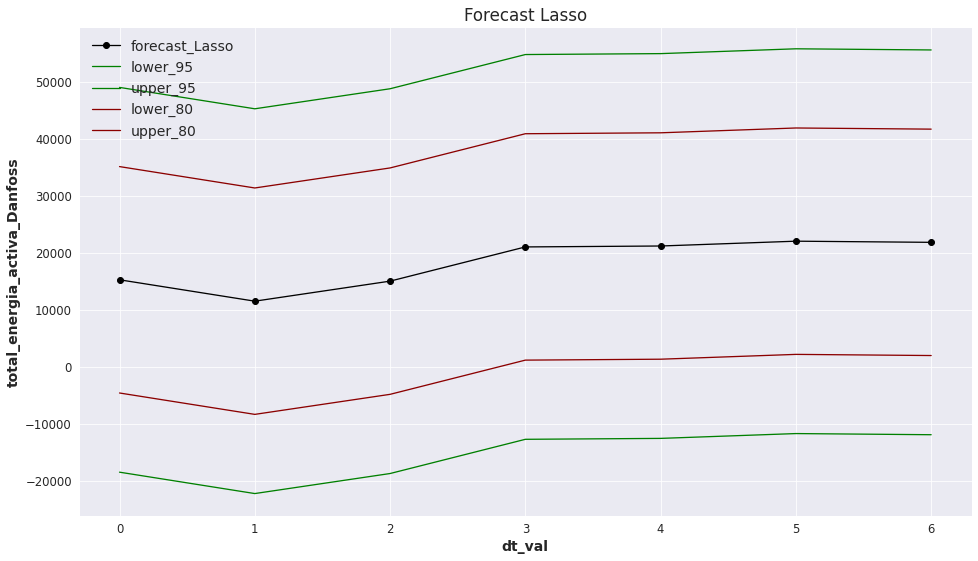

In [86]:
lambda_handler()